In [1]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
from ultralytics.data.split_dota import split_trainval, split_images_and_labels
import os
import shutil
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# ścieżki

# źródło
source_data_path = Path("/content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit")

# źródło przygotowane pod slicing
source_data_path_slicing = Path("/content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_prepare_slicing")

# docelowe
target_data_path = Path("/content/EAGLE_Dataset_public_edit_slicing")

# docelowa ścieżka zip na dysku
target_zip_catalog = Path("/content/drive/MyDrive/dane_detekcja_pojazdow")

# podkatalogi
train_dir = "train"
val_dir = "val"
test_dir = "test"

# podkatalogi: images, labels
images_dir = "images"
labels_dir = "labels"

# Przygotowanie katalogów do operacji kafelkowania

In [ ]:
# utworzenie katalogu
for il_dir in [images_dir, labels_dir]:
  for tv_dir in [train_dir, val_dir]:
    path_ = source_data_path_slicing / il_dir / tv_dir
    path_.mkdir(parents=True, exist_ok=True)

    source_path = source_data_path / tv_dir / il_dir
    for file_ in source_path.glob("*"):
      shutil.copy(file_, path_)


In [ ]:
# liczba danych w katalogach
print("Skopiowane")
for il_dir in [images_dir, labels_dir]:
  for tv_dir in [train_dir, val_dir]:
      path_ = source_data_path_slicing / il_dir / tv_dir
      print(f"{path_.parent.name}\\{path_.name}: {len(list(path_.glob('*')))}")

print("")
print("Oryginał")
for il_dir in [images_dir, labels_dir]:
  for tv_dir in [train_dir, val_dir]:
      path_ = source_data_path / tv_dir / il_dir
      print(f"{path_.parent.name}\\{path_.name}: {len(list(path_.glob('*')))}")

Skopiowane
images\train: 159
images\val: 53
labels\train: 159
labels\val: 53

Oryginał
train\images: 159
val\images: 53
train\labels: 159
val\labels: 53


# Kafelkowanie

In [ ]:
#zalecane parametry

# CROP_SIZE = 1024

# GAP = 256

# RATES = (0.5, 1.0, 2.0)

In [ ]:
# umiarkowana wersja jeśli chodzi o ilość danych
split_trainval(
    str(source_data_path_slicing),
    str(target_data_path),
    crop_size=1024,
    gap=256,
    rates= (1.0, 0.5)
)

val: 100% ━━━━━━━━━━━━ 53/53 3.3s/it 2:57
train: 100% ━━━━━━━━━━━━ 159/159 3.5s/it 9:10


In [5]:
# większa ilość danych

target_data_path_more = Path("/content/EAGLE_Dataset_public_edit_slicing_more")

split_trainval(
    str(source_data_path_slicing),
    str(target_data_path_more),
    crop_size=1024,
    gap=256,
    rates= (0.5, 1.0, 2.0)
)

train: 100% ━━━━━━━━━━━━ 159/159 1.7s/it 4:23
val: 100% ━━━━━━━━━━━━ 53/53 2.7s/it 2:24


# Test wizualny

In [ ]:
def visualize_converted_boxes(image_file_name, subfolder='train'):
    """
    Wizualizuje skonwertowane ramki OBB (9-kolumnowe) na obrazie.

    Zakłada, że zmienne globalne 'data_path' i 'data_copy_path'
    są zdefiniowane poza tą funkcją.

    Argumenty:
    image_file_name (str): Nazwa pliku obrazu (np. "moj_obraz.JPG")
    subfolder (str): Podfolder, w którym jest obraz (np. 'train', 'val', 'test')
    """

    # 1. Automatycznie utwórz nazwę pliku etykiety z nazwy obrazu
    #    (np. "obraz.JPG" -> "obraz.txt")
    label_file_name = Path(image_file_name).stem + '.txt'

    # 2. Zbuduj pełne ścieżki
    image_path = target_data_path / 'images' / subfolder / image_file_name
    new_label_path = target_data_path / 'labels' / subfolder / label_file_name

    # 3. Sprawdź, czy pliki istnieją
    if not image_path.exists():
        print(f"BŁĄD: Nie znaleziono obrazu: {image_path}")
        return  # Zakończ funkcję

    if not new_label_path.exists():
        print(f"BŁĄD: Nie znaleziono NOWEJ etykiety: {new_label_path}")
        print("Sprawdź, czy uruchomiłeś skrypt konwertujący Krok 3.")
        return  # Zakończ funkcję

    # 4. Wczytaj obraz i etykiety (ten sam kod co poprzednio)
    print(f"Weryfikacja wizualna dla: {image_file_name} (z folderu {subfolder})")
    img = cv2.imread(str(image_path))

    if img is None:
        print(f"BŁĄD: Nie można było wczytać obrazu z {image_path}")
        return

    h, w, _ = img.shape
    boxes_drawn = 0

    with open(new_label_path, 'r') as f:
        # Pętla przez wszystkie linie
        for line in f:
            parts = line.strip().split()

            if len(parts) == 9:
                boxes_drawn += 1
                points_norm = [float(p) for p in parts[1:]]

                points_abs = []
                for i in range(0, 8, 2):
                    x_norm, y_norm = points_norm[i], points_norm[i+1]
                    x_abs, y_abs = int(x_norm * w), int(y_norm * h)
                    points_abs.append([x_abs, y_abs])

                pts_np = np.array(points_abs, dtype=np.int32).reshape((-1, 1, 2))
                cv2.polylines(img, [pts_np], isClosed=True, color=(0, 255, 0), thickness=2)

    # 5. Wyświetl wynik
    if boxes_drawn > 0:
        print(f"Narysowano {boxes_drawn} ramek.")
        cv2_imshow(img)
    else:
        print("Nie znaleziono żadnych poprawnych etykiet (9 kolumn) w pliku.")

Weryfikacja wizualna dla: 2012-04-26-Muenchen-Tunnel_4K0G0020__1024__3072___1536.jpg (z folderu train)
Narysowano 9 ramek.


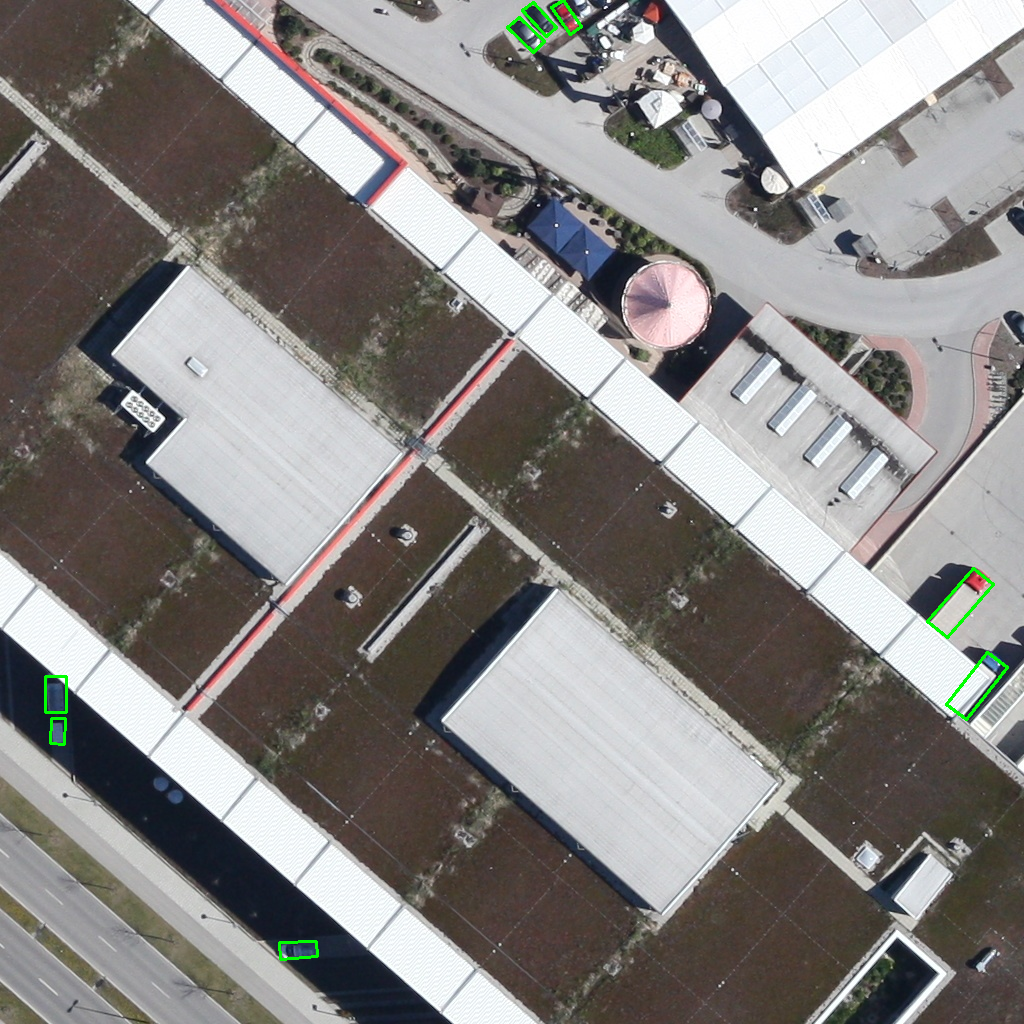

In [ ]:
visualize_converted_boxes("2012-04-26-Muenchen-Tunnel_4K0G0020__1024__3072___1536.jpg")

# Zapis na dysk w celu weryfikacji ramek

In [ ]:
def save_image_with_obb(image_file_path):

    # Zbuduj pełne ścieżki
    image_path = image_file_path

    subfolder = image_file_path.parent.name
    new_label_path = target_data_path / 'labels' / subfolder / (image_file_path.stem + '.txt')

    # 3. Sprawdź, czy pliki istnieją
    if not image_path.exists():
        print(f"BŁĄD: Nie znaleziono obrazu: {image_path}")
        return  # Zakończ funkcję

    if not new_label_path.exists():
        print(f"BŁĄD: Nie znaleziono NOWEJ etykiety: {new_label_path}")
        print("Sprawdź, czy uruchomiłeś skrypt konwertujący Krok 3.")
        return  # Zakończ funkcję

    # 4. Wczytaj obraz i etykiety (ten sam kod co poprzednio)
    img = cv2.imread(str(image_path))

    if img is None:
        print(f"BŁĄD: Nie można było wczytać obrazu z {image_path}")
        return

    h, w, _ = img.shape
    boxes_drawn = 0

    with open(new_label_path, 'r') as f:
        # Pętla przez wszystkie linie
        for line in f:
            parts = line.strip().split()

            if len(parts) == 9:
                boxes_drawn += 1
                points_norm = [float(p) for p in parts[1:]]

                points_abs = []
                for i in range(0, 8, 2):
                    x_norm, y_norm = points_norm[i], points_norm[i+1]
                    x_abs, y_abs = int(x_norm * w), int(y_norm * h)
                    points_abs.append([x_abs, y_abs])

                pts_np = np.array(points_abs, dtype=np.int32).reshape((-1, 1, 2))
                cv2.polylines(img, [pts_np], isClosed=True, color=(0, 255, 0), thickness=2)

    # 5. Zapisz wynik
    if boxes_drawn > 0:

        draw_obb_path = Path("/content/drive/MyDrive/dane_detekcja_pojazdow/draw_obb")
        save_path = draw_obb_path / "scliced"

        save_path.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(save_path / image_file_path.name), img)
        print(f"Zapisano obraz z ramkami: {image_file_path.name}")
    else:
        print("Nie znaleziono żadnych poprawnych etykiet (9 kolumn) w pliku.")

In [ ]:
# images_path_sliced = Path(
#     "/content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit_slicing/images"
#     )

# for subfolder in ["train", "val"]:
#   path_images = images_path_sliced / subfolder
#   for image_file in path_images.glob("*"):
#     save_image_with_obb(image_file)

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
BŁĄD: Nie znaleziono NOWEJ etykiety: /content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit_slicing/labels/train/2015-11-04-Magdeburg-R-R0780__1024__2432___0.txt
Sprawdź, czy uruchomiłeś skrypt konwertujący Krok 3.
BŁĄD: Nie znaleziono NOWEJ etykiety: /content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit_slicing/labels/train/2015-11-04-Magdeburg-R-R0780__1024__2432___768.txt
Sprawdź, czy uruchomiłeś skrypt konwertujący Krok 3.
BŁĄD: Nie znaleziono NOWEJ etykiety: /content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit_slicing/labels/train/2015-11-04-Magdeburg-R-R0780__1024__2432___1536.txt
Sprawdź, czy uruchomiłeś skrypt konwertujący Krok 3.
BŁĄD: Nie znaleziono NOWEJ etykiety: /content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit_slicing/labels/train/2015-11-04-Magdeburg-R-R0780__1024__2432___2304.txt
Sprawdź, czy uruchomiłeś skrypt konwertujący Krok 3.

# Kafelkowanie zbioru testowego

In [6]:
# funkcja kafelkująca zbiór testowy
def my_split_test(source_data_path: Path, target_data_path: Path, crop_size: int = 1024, gap: int = 200):
    source_data_path = Path(source_data_path)
    target_data_path = Path(target_data_path)

    # 1. Konfiguracja tymczasowego środowiska
    # Używamy "train" jako nazwy splitu, aby funkcja Ultralytics przetworzyła też etykiety
    temp_root = Path("/content/temp_test_env")
    temp_split = "train"

    # tymczasowy folder do zapisu
    temp_target = Path("/content/temp_target")
    temp_target.mkdir(parents=True, exist_ok=True)

    # Tworzymy strukturę, której wymaga skrypt: root/images/train oraz root/labels/train
    temp_imgs_dir = temp_root / "images" / temp_split
    temp_lbls_dir = temp_root / "labels" / temp_split

    # Czyścimy folder tymczasowy jeśli istnieje, żeby uniknąć błędów
    if temp_root.exists():
        shutil.rmtree(temp_root)

    temp_imgs_dir.mkdir(parents=True, exist_ok=True)
    temp_lbls_dir.mkdir(parents=True, exist_ok=True)

    # 2. Mapowanie Twojej struktury (source/test/images) na strukturę Ultralytics (temp/images/train)
    # Uwaga: Twoja struktura źródłowa ma odwróconą kolejność (test/images zamiast images/test)
    source_imgs = source_data_path / "test" / "images"
    source_lbls = source_data_path / "test" / "labels"

    print(f"Tworzenie dowiązań symbolicznych z {source_data_path} do {temp_root}...")

    # Linkowanie obrazów
    if source_imgs.exists():
        for img_file in source_imgs.glob("*"):
            if img_file.is_file():
                # Tworzymy symlink w temp/images/train/obraz.jpg -> source/test/images/obraz.jpg
                os.symlink(img_file, temp_imgs_dir / img_file.name)
    else:
        print(f"Ostrzeżenie: Nie znaleziono katalogu obrazów: {source_imgs}")

    # Linkowanie etykiet
    if source_lbls.exists():
        for lbl_file in source_lbls.glob("*"):
            if lbl_file.is_file():
                os.symlink(lbl_file, temp_lbls_dir / lbl_file.name)
    else:
        print(f"Ostrzeżenie: Nie znaleziono katalogu etykiet: {source_lbls}")

    # 3. Uruchomienie procesu kafelkowania (splitting)
    # Funkcja myśli, że przetwarza zbiór 'train', więc potnie i obrazy, i etykiety
    print("Rozpoczynanie kafelkowania (splitting)...")
    split_images_and_labels(
        data_root=str(temp_root),
        save_dir=str(temp_target),
        split=temp_split,  # "train"
        crop_sizes=(crop_size,),
        gaps=(gap,)
    )

    # 4. Sprzątanie i przenoszenie wyników do folderu docelowego "test"
    print("Porządkowanie struktury katalogów docelowych...")

    # Skrypt utworzył: target/images/train i target/labels/train
    # My chcemy: target/images/test i target/labels/test

    generated_imgs = temp_target / "images" / temp_split
    generated_lbls = temp_target / "labels" / temp_split

    final_imgs = target_data_path / "images" / "test"
    final_lbls = target_data_path / "labels" / "test"

    # Usuń stare foldery test w target, jeśli istnieją (dla czystego startu)
    if final_imgs.exists(): shutil.rmtree(final_imgs)
    if final_lbls.exists(): shutil.rmtree(final_lbls)

    # Zmień nazwę folderów z 'train' na 'test'
    if generated_imgs.exists():
        generated_imgs.rename(final_imgs)
    if generated_lbls.exists():
        generated_lbls.rename(final_lbls)

    # 5. Usunięcie folderu tymczasowego z symlinkami
    if temp_root.exists():
        shutil.rmtree(temp_root)

    if temp_target.exists():
        shutil.rmtree(temp_target)

    print(f"Gotowe! Pocięty zbiór testowy (z etykietami) znajduje się w: {target_data_path}")

  # kafelkowanie

# # copy test
# def copy_test(source_data_path: Path, target_data_path: Path):
#   for subfolder in ["images", "labels"]:
#     path_source = source_data_path / "test" / subfolder
#     path_target = target_data_path / subfolder / "test"

#     path_target.mkdir(parents=True, exist_ok=True)
#     for file_ in path_source.glob("*"):
#       if file_.is_file():
#         shutil.copy(file_, path_target)
#       else:
#         print(f"Błąd: {file_} nie jest plikiem")


In [7]:
source_test_data_path = Path("/content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit")

In [ ]:
my_split_test(source_test_data_path, target_data_path, crop_size = 1024, gap = 256)

In [8]:
my_split_test(source_test_data_path, target_data_path_more, crop_size = 1024, gap = 256)

Tworzenie dowiązań symbolicznych z /content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit do /content/temp_test_env...
Rozpoczynanie kafelkowania (splitting)...
train: 100% ━━━━━━━━━━━━ 106/106 1.3it/s 1:23
Porządkowanie struktury katalogów docelowych...
Gotowe! Pocięty zbiór testowy (z etykietami) znajduje się w: /content/EAGLE_Dataset_public_edit_slicing_more


In [15]:
# wyświetlenie pierwszych 5 plików folderze
path_files_to_show = Path("/content/EAGLE_Dataset_public_edit_slicing_more/labels/test")

for file_ in list(path_files_to_show.glob("*"))[:5]:
  print(str(file_))

/content/EAGLE_Dataset_public_edit_slicing_more/labels/test/2013-08-02-Frankfurt-mitte-4K0G0171__1024__1536___2720.txt
/content/EAGLE_Dataset_public_edit_slicing_more/labels/test/2008-11-28-Muenchen-Verkehr-mitte-yp3x0255__1024__768___1536.txt
/content/EAGLE_Dataset_public_edit_slicing_more/labels/test/2011-07-07-Tollwood--mitte-5V4B0008__1024__4592___1536.txt
/content/EAGLE_Dataset_public_edit_slicing_more/labels/test/2018-06-04-HySpex-OP-original-mitte_4K0G0857__1024__3072___1536.txt
/content/EAGLE_Dataset_public_edit_slicing_more/labels/test/2016-08-04-wacken-Satz3-rechts-R0678__1024__768___4160.txt


# Zapis do struktury YOLO

In [16]:
def create_yaml(path_yaml):
  # Tworzenie pliku data.yaml
  file_yaml_text = f"""
  path: {path_yaml}  # Główna ścieżka (root)

  train: images/train       # Wskazujemy podfolder images/train
  val: images/val           # Wskazujemy podfolder images/val
  test: images/test         # Wskazujemy podfolder images/test (opcjonalnie)

  # Definicja klas
  nc: 1
  names: ['vehicle']
  """

  yaml_file_path = path_yaml / 'data.yaml'

  with open(yaml_file_path, 'w') as f:
      f.write(file_yaml_text)

  print(f"Utworzono plik konfiguracyjny: {yaml_file_path}")
  print("Możesz teraz trenować model wskazując ten plik .yaml")


In [ ]:
create_yaml(target_data_path)

In [17]:
create_yaml(target_data_path_more)

Utworzono plik konfiguracyjny: /content/EAGLE_Dataset_public_edit_slicing_more/data.yaml
Możesz teraz trenować model wskazując ten plik .yaml


In [ ]:
!pip install seedir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.0/114.0 kB 4.7 MB/s eta 0:00:00


In [ ]:
import seedir as sd

sd.seedir(target_data_path_more, style='lines', itemlimit=5, depthlimit=2)


EAGLE_Dataset_public_edit_slicing_more/
├─images/
│ ├─train/
│ ├─val/
│ └─test/
├─labels/
│ ├─train/
│ ├─val/
│ └─test/
└─data.yaml


## Pakowanie do zip wewnątrz dysku google

In [18]:
zip_file_path = target_zip_catalog / "EAGLE_Dataset_public_edit_slicing_more.zip"
folder_to_zip_path = target_data_path_more

!zip -q -r "{zip_file_path}" "{folder_to_zip_path}"